# LASSA SEROPREVALENCE MACHINE LEARNING
## SECTION 4: XGBOOST (IMBALANCE‑AWARE) — CV, THRESHOLDS, PLOTS, SAVED ARTIFACTS (FULL NOTEBOOK)

**What this notebook does (end‑to‑end):**
1) Loads the dataset locally
2) Cleans strings and drops leakage/ID columns
3) Drops high‑cardinality columns that hurt generalization (**Town/City**, **Occupation**)
4) Builds a preprocessing pipeline (impute + scale numeric, impute + one‑hot categorical)
5) Runs **3‑fold Stratified CV** and generates **out‑of‑fold (OOF)** probabilities
6) Selects and saves **3 thresholds**:
   - **Screening (High Recall)**
   - **Balanced (Best F1)**
   - **Confirmatory (High Precision)** (may coincide with Best F1)
7) Produces and saves high quality plots:
   - OOF Precision‑Recall curve
   - OOF ROC curve
   - Threshold sweep curves (F1/Precision/Recall)
   - Confusion matrices for each operating mode
8) Trains a final model on the full dataset and saves artifacts:
   - `models/section4_preprocess_drop.joblib`
   - `models/section4_xgb_drop_pipeline.joblib`
   - `models/section4_xgb_drop_model.json`
   - `results/reports/section4_final_summary.json`

---

### Important reality
Your dataset has **3 positives total**, so all estimates are noisy. This notebook is built to be as rigorous as possible under that constraint.


---

## CELL 4.0: IMPORTS + FOLDER SETUP + GLOBAL SETTINGS

Creates required directories and sets plotting style.


In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

import xgboost as xgb

print("\n" + "="*100)
print("SECTION 4: FULL XGBOOST TRAINING + CV + THRESHOLDS + PLOTS + SAVING")
print("="*100)

# Repro
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Directories
Path("data/splits").mkdir(parents=True, exist_ok=True)
Path("models").mkdir(parents=True, exist_ok=True)
Path("results/plots").mkdir(parents=True, exist_ok=True)
Path("results/reports").mkdir(parents=True, exist_ok=True)

print("✓ Directories ready:")
print("  data/splits/")
print("  models/")
print("  results/plots/")
print("  results/reports/")

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 7),
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
print("Run timestamp:", RUN_TS)



SECTION 4: FULL XGBOOST TRAINING + CV + THRESHOLDS + PLOTS + SAVING
✓ Directories ready:
  data/splits/
  models/
  results/plots/
  results/reports/
Run timestamp: 20260331_183849


---

## CELL 4.1: LOAD DATA (LOCAL ONLY) + CLEANING + TARGET MAPPING

### Actions
- Load CSV locally
- Strip whitespace for all object columns
- Drop `Full_Name` and `Patient_ID`
- Map target to 0/1


In [3]:
# Update this if your local file path changes
DATA_PATH = "data/LASV_Master_Data!.csv"
TARGET_COL = "lab_results.PCR_Results"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Missing dataset at: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

# Strip all object columns (fixes 'Female ' etc.)
for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype(str).str.strip()

# Drop leakage/ID columns
df = df.drop(columns=["Full_Name", "Patient_ID"], errors="ignore")

# Target mapping
mapping = {"No Kb (Negative)": 0, "320Kb (Positive)": 1}
y = df[TARGET_COL].map(mapping)
if y.isna().any():
    bad = df.loc[y.isna(), TARGET_COL].unique().tolist()
    raise ValueError(f"Unmapped target values found: {bad}")

y = y.astype(int).values
X = df.drop(columns=[TARGET_COL])

print("\n" + "="*100)
print("CELL 4.1 COMPLETE: DATA LOADED")
print("="*100)
print("X shape:", X.shape)
print("Positives:", int((y==1).sum()), "Negatives:", int((y==0).sum()))



CELL 4.1 COMPLETE: DATA LOADED
X shape: (250, 43)
Positives: 3 Negatives: 247


---

## CELL 4.2: DROP HIGH‑CARDINALITY COLUMNS (FINAL DIRECTION)

We drop:
- `Town/City`
- `Occupation`

because it improved OOF PR‑AUC in your experiments.


In [4]:
DROP_COLS = [c for c in ["Town/City", "Occupation"] if c in X.columns]
X_drop = X.drop(columns=DROP_COLS, errors="ignore").copy()

print("\n" + "="*100)
print("CELL 4.2 COMPLETE: HIGH‑CARDINALITY DROPPED")
print("="*100)
print("Dropped columns:", DROP_COLS)
print("New X_drop shape:", X_drop.shape)



CELL 4.2 COMPLETE: HIGH‑CARDINALITY DROPPED
Dropped columns: ['Town/City', 'Occupation']
New X_drop shape: (250, 41)


---

## CELL 4.3: PREPROCESS PIPELINE (DROP VERSION)

- Numeric: median impute + StandardScaler
- Categorical: most_frequent impute + OneHotEncoder


In [5]:
num_cols = X_drop.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_drop.select_dtypes(include=["object"]).columns.tolist()

preprocess_drop = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("\n" + "="*100)
print("CELL 4.3 COMPLETE: PREPROCESS PIPELINE READY")
print("="*100)
print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))



CELL 4.3 COMPLETE: PREPROCESS PIPELINE READY
Numeric cols: 3 Categorical cols: 38


---

## CELL 4.4: SAVE A REPRODUCIBLE TRAIN/TEST SPLIT (OPTIONAL HOLDOUT)

Even though CV is our main evaluation, we also save a holdout split for demonstrations.
We use a safety loop to ensure at least 1 positive in test if possible.


In [6]:
def safe_stratified_split(Xdf, yarr, test_size=0.2, base_seed=42, max_tries=300, min_pos_test=1):
    for i in range(max_tries):
        seed = base_seed + i
        X_tr, X_te, y_tr, y_te = train_test_split(
            Xdf, yarr, test_size=test_size, random_state=seed, stratify=yarr
        )
        if (y_te == 1).sum() >= min_pos_test:
            return X_tr, X_te, y_tr, y_te, seed
    return X_tr, X_te, y_tr, y_te, seed

X_train, X_test, y_train, y_test, split_seed = safe_stratified_split(X_drop, y, test_size=0.2, base_seed=RANDOM_SEED)

Path("data/splits").mkdir(parents=True, exist_ok=True)
X_train.to_csv("data/splits/section4_X_train.csv", index=False)
X_test.to_csv("data/splits/section4_X_test.csv", index=False)
pd.Series(y_train, name="y_train").to_csv("data/splits/section4_y_train.csv", index=False)
pd.Series(y_test, name="y_test").to_csv("data/splits/section4_y_test.csv", index=False)

print("\n" + "="*100)
print("CELL 4.4 COMPLETE: SPLITS SAVED")
print("="*100)
print("Split seed:", split_seed)
print("Train positives:", int((y_train==1).sum()), "Test positives:", int((y_test==1).sum()))
print("Saved:")
print("  data/splits/section4_X_train.csv")
print("  data/splits/section4_X_test.csv")
print("  data/splits/section4_y_train.csv")
print("  data/splits/section4_y_test.csv")



CELL 4.4 COMPLETE: SPLITS SAVED
Split seed: 42
Train positives: 2 Test positives: 1
Saved:
  data/splits/section4_X_train.csv
  data/splits/section4_X_test.csv
  data/splits/section4_y_train.csv
  data/splits/section4_y_test.csv


---

## CELL 4.5: OOF CV (3‑FOLD) + OOF PROBABILITIES (DROP VERSION)

We use **3 folds** because you only have **3 positives**.
This ensures each validation fold has 1 positive sample.


In [7]:
skf3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

oof_proba = np.zeros(len(X_drop), dtype=float)
fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(skf3.split(X_drop, y), 1):
    X_tr, X_va = X_drop.iloc[tr_idx], X_drop.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    neg = int((y_tr == 0).sum())
    pos = int((y_tr == 1).sum())
    spw = neg / max(pos, 1)

    # Fit transform with preprocess
    Xt_tr = preprocess_drop.fit_transform(X_tr)
    Xt_va = preprocess_drop.transform(X_va)

    model = xgb.XGBClassifier(
        n_estimators=2500,
        learning_rate=0.02,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        min_child_weight=2,
        gamma=0,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=spw,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    model.fit(Xt_tr, y_tr, eval_set=[(Xt_va, y_va)], verbose=False)

    proba = model.predict_proba(Xt_va)[:, 1]
    oof_proba[va_idx] = proba

    pr_auc = average_precision_score(y_va, proba)
    fold_rows.append({
        "fold": fold,
        "val_size": int(len(va_idx)),
        "val_pos": int((y_va==1).sum()),
        "scale_pos_weight": float(spw),
        "pr_auc": float(pr_auc)
    })

fold_df = pd.DataFrame(fold_rows)
oof_pr_auc = average_precision_score(y, oof_proba)
oof_roc_auc = roc_auc_score(y, oof_proba)

fold_df.to_csv("results/reports/section4_oof_3fold_folds.csv", index=False)
pd.DataFrame({"oof_proba": oof_proba, "y": y}).to_csv("results/reports/section4_oof_3fold_predictions.csv", index=False)

print("\n" + "="*100)
print("CELL 4.5 COMPLETE: OOF CV DONE")
print("="*100)
print(fold_df)
print("\nOOF PR-AUC:", oof_pr_auc)
print("OOF ROC-AUC:", oof_roc_auc)
print("Saved:")
print("  results/reports/section4_oof_3fold_folds.csv")
print("  results/reports/section4_oof_3fold_predictions.csv")



CELL 4.5 COMPLETE: OOF CV DONE
   fold  val_size  val_pos  scale_pos_weight    pr_auc
0     1        84        1              82.0  0.030303
1     2        83        1              82.5  0.040000
2     3        83        1              82.5  0.333333

OOF PR-AUC: 0.05740740740740741
OOF ROC-AUC: 0.7786774628879891
Saved:
  results/reports/section4_oof_3fold_folds.csv
  results/reports/section4_oof_3fold_predictions.csv


---

## CELL 4.6: THRESHOLD SWEEP + 3 OPERATING MODES (SAVE)

We compute and store three thresholds:
- Screening (maximize recall)
- Balanced (maximize F1)
- Confirmatory (maximize precision with predicted positives > 0)


In [8]:
thresholds = np.linspace(0.001, 0.5, 500)
rows = []
for t in thresholds:
    y_hat = (oof_proba >= t).astype(int)
    rows.append({
        "threshold": float(t),
        "f1": float(f1_score(y, y_hat, zero_division=0)),
        "precision": float(precision_score(y, y_hat, zero_division=0)),
        "recall": float(recall_score(y, y_hat, zero_division=0)),
        "predicted_positives": int(y_hat.sum())
    })

th_df = pd.DataFrame(rows)

best_recall = th_df.sort_values(["recall", "precision"], ascending=False).iloc[0]
best_f1 = th_df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
cand = th_df[th_df["predicted_positives"] > 0]
best_precision = cand.sort_values(["precision", "recall", "f1"], ascending=False).iloc[0]

threshold_choices = {
    "screening_high_recall": best_recall.to_dict(),
    "balanced_best_f1": best_f1.to_dict(),
    "confirmatory_high_precision": best_precision.to_dict()
}

th_df.to_csv("results/reports/section4_threshold_sweep.csv", index=False)
with open("results/reports/section4_threshold_choices.json", "w") as f:
    json.dump({
        "generated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "oof_pr_auc": float(oof_pr_auc),
        "oof_roc_auc": float(oof_roc_auc),
        "choices": threshold_choices
    }, f, indent=2)

print("\n" + "="*100)
print("CELL 4.6 COMPLETE: THRESHOLDS SELECTED")
print("="*100)
print(json.dumps(threshold_choices, indent=2))
print("Saved:")
print("  results/reports/section4_threshold_sweep.csv")
print("  results/reports/section4_threshold_choices.json")



CELL 4.6 COMPLETE: THRESHOLDS SELECTED
{
  "screening_high_recall": {
    "threshold": 0.006,
    "f1": 0.0594059405940594,
    "precision": 0.030612244897959183,
    "recall": 1.0,
    "predicted_positives": 98.0
  },
  "balanced_best_f1": {
    "threshold": 0.113,
    "f1": 0.16666666666666666,
    "precision": 0.1111111111111111,
    "recall": 0.3333333333333333,
    "predicted_positives": 9.0
  },
  "confirmatory_high_precision": {
    "threshold": 0.113,
    "f1": 0.16666666666666666,
    "precision": 0.1111111111111111,
    "recall": 0.3333333333333333,
    "predicted_positives": 9.0
  }
}
Saved:
  results/reports/section4_threshold_sweep.csv
  results/reports/section4_threshold_choices.json


---

## CELL 4.7: OOF CURVES (PR + ROC) + THRESHOLD CURVES (SAVE PLOTS)

Generates high-quality saved plots in `results/plots/`.


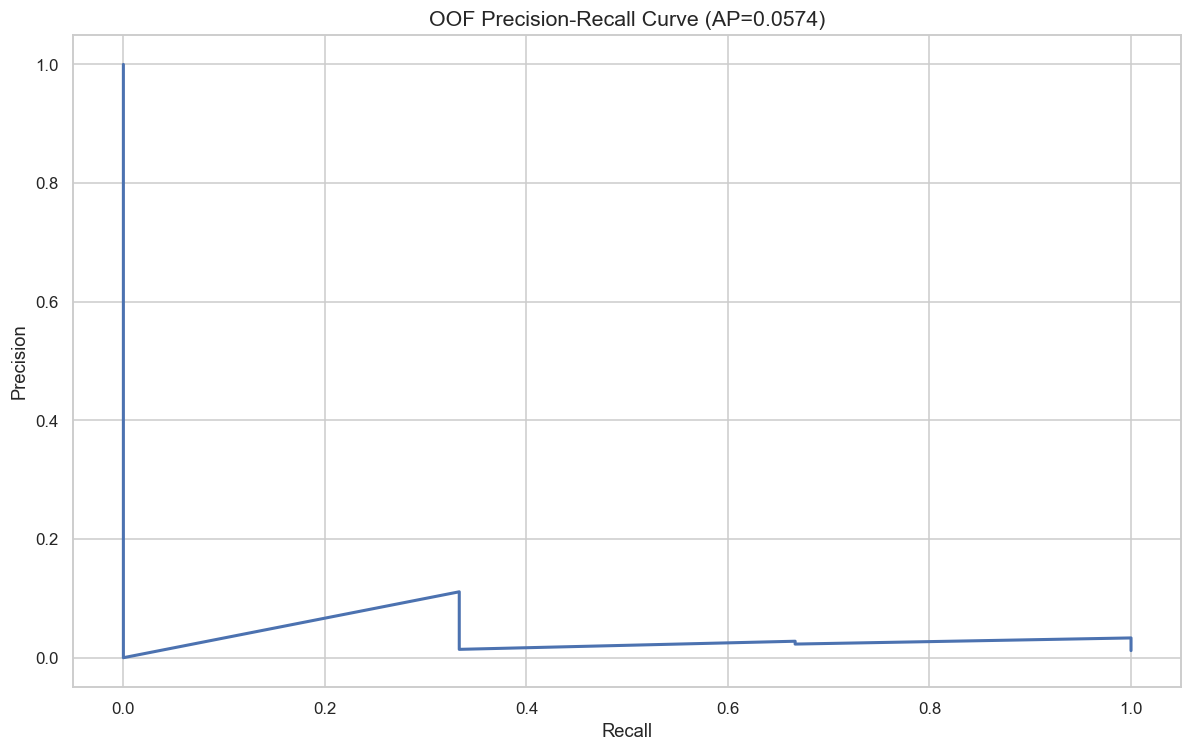

✓ Saved: results/plots/section4_oof_pr_curve.png


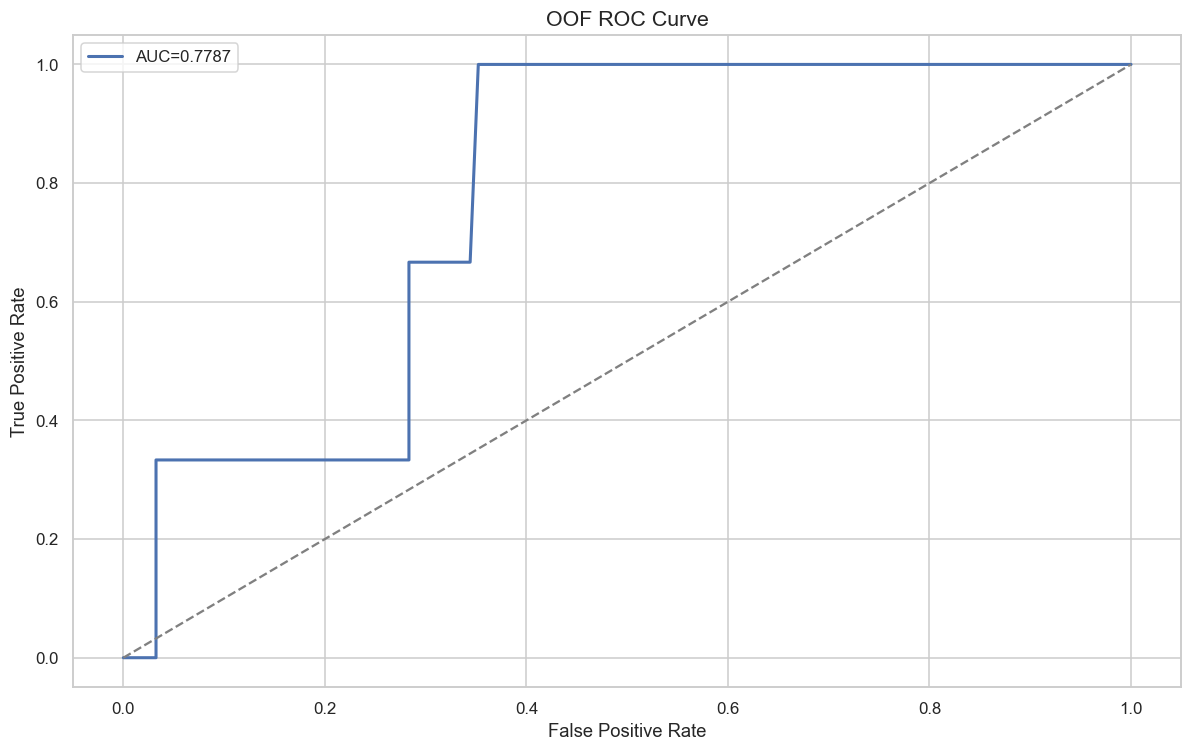

✓ Saved: results/plots/section4_oof_roc_curve.png


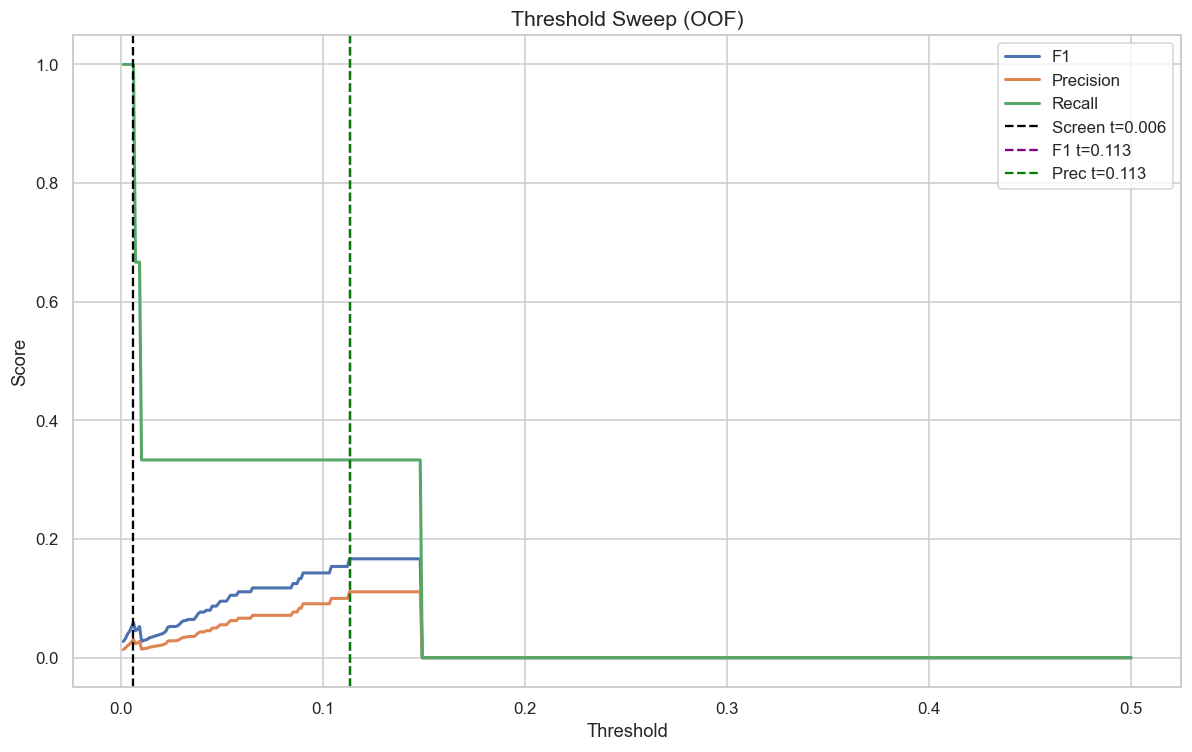

✓ Saved: results/plots/section4_threshold_sweep.png


In [9]:
# 1) Precision-Recall curve (OOF)
prec, rec, _ = precision_recall_curve(y, oof_proba)
ap = average_precision_score(y, oof_proba)

plt.figure()
plt.plot(rec, prec, linewidth=2)
plt.title(f"OOF Precision-Recall Curve (AP={ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.savefig("results/plots/section4_oof_pr_curve.png")
plt.show()
print("✓ Saved: results/plots/section4_oof_pr_curve.png")

# 2) ROC curve (OOF)
fpr, tpr, _ = roc_curve(y, oof_proba)
auc_val = roc_auc_score(y, oof_proba)

plt.figure()
plt.plot(fpr, tpr, linewidth=2, label=f"AUC={auc_val:.4f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.title("OOF ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/section4_oof_roc_curve.png")
plt.show()
print("✓ Saved: results/plots/section4_oof_roc_curve.png")

# 3) Threshold sweep curves
plt.figure()
plt.plot(th_df["threshold"], th_df["f1"], label="F1", linewidth=2)
plt.plot(th_df["threshold"], th_df["precision"], label="Precision", linewidth=2)
plt.plot(th_df["threshold"], th_df["recall"], label="Recall", linewidth=2)

t_r = float(threshold_choices["screening_high_recall"]["threshold"])
t_f = float(threshold_choices["balanced_best_f1"]["threshold"])
t_p = float(threshold_choices["confirmatory_high_precision"]["threshold"])

plt.axvline(t_r, color="black", linestyle="--", label=f"Screen t={t_r:.3f}")
plt.axvline(t_f, color="purple", linestyle="--", label=f"F1 t={t_f:.3f}")
plt.axvline(t_p, color="green", linestyle="--", label=f"Prec t={t_p:.3f}")

plt.title("Threshold Sweep (OOF)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/section4_threshold_sweep.png")
plt.show()
print("✓ Saved: results/plots/section4_threshold_sweep.png")


---

## CELL 4.8: CONFUSION MATRICES FOR EACH OPERATING MODE (OOF) + SAVE PLOTS

We compute confusion matrices using OOF predictions at each threshold.



----------------------------------------------------------------------------------------------------
screening_high_recall threshold= 0.006
Confusion matrix:
 [[152  95]
 [  0   3]]
Report:
               precision    recall  f1-score   support

           0     1.0000    0.6154    0.7619       247
           1     0.0306    1.0000    0.0594         3

    accuracy                         0.6200       250
   macro avg     0.5153    0.8077    0.4107       250
weighted avg     0.9884    0.6200    0.7535       250



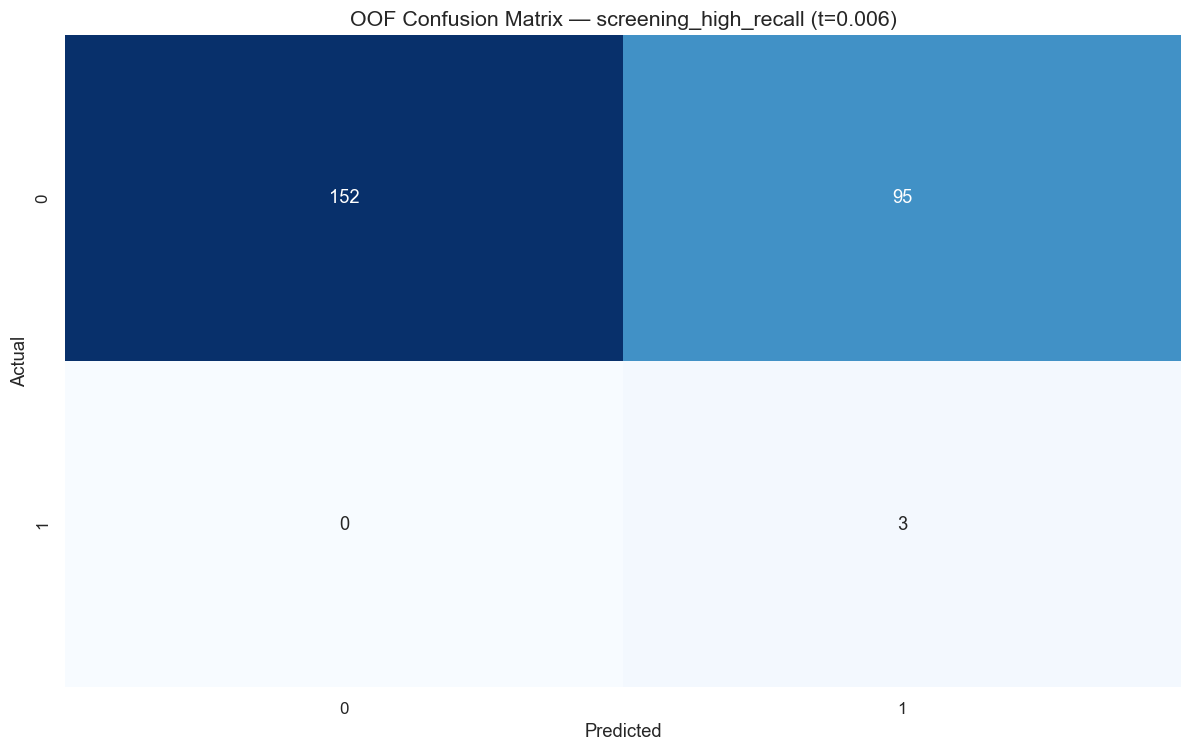

✓ Saved: results/plots/section4_cm_screening_high_recall.png

----------------------------------------------------------------------------------------------------
balanced_best_f1 threshold= 0.113
Confusion matrix:
 [[239   8]
 [  2   1]]
Report:
               precision    recall  f1-score   support

           0     0.9917    0.9676    0.9795       247
           1     0.1111    0.3333    0.1667         3

    accuracy                         0.9600       250
   macro avg     0.5514    0.6505    0.5731       250
weighted avg     0.9811    0.9600    0.9698       250



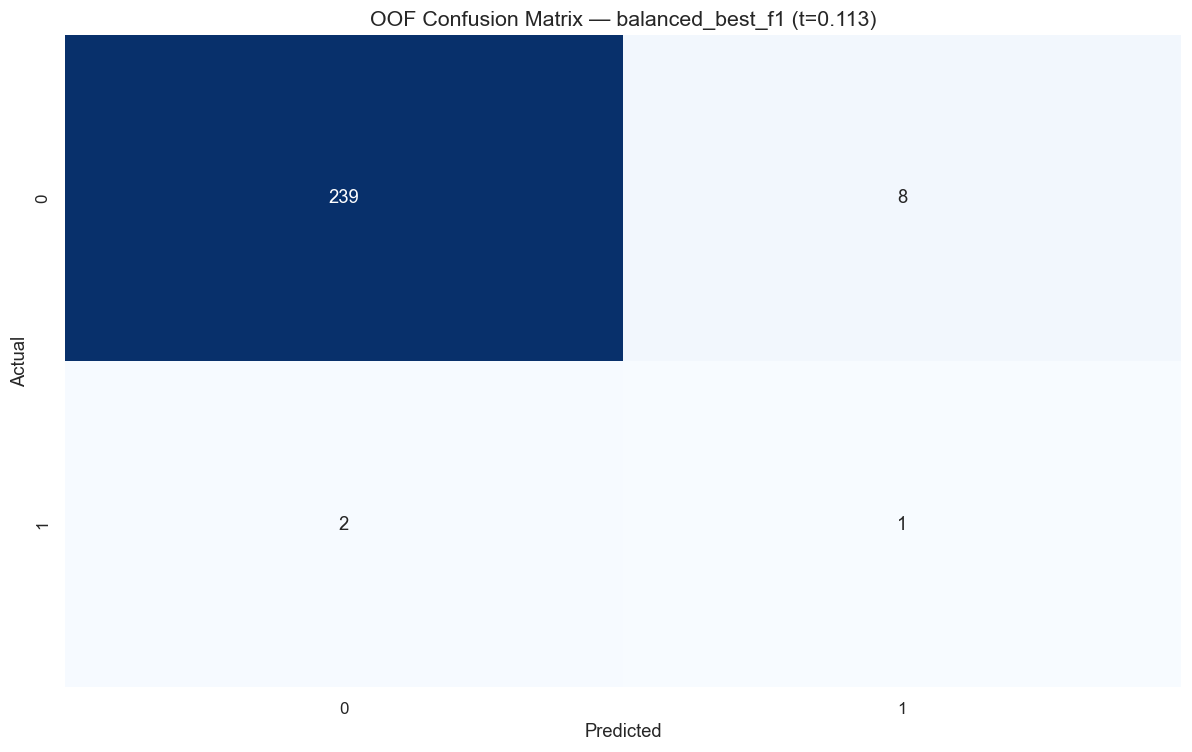

✓ Saved: results/plots/section4_cm_balanced_best_f1.png

----------------------------------------------------------------------------------------------------
confirmatory_high_precision threshold= 0.113
Confusion matrix:
 [[239   8]
 [  2   1]]
Report:
               precision    recall  f1-score   support

           0     0.9917    0.9676    0.9795       247
           1     0.1111    0.3333    0.1667         3

    accuracy                         0.9600       250
   macro avg     0.5514    0.6505    0.5731       250
weighted avg     0.9811    0.9600    0.9698       250



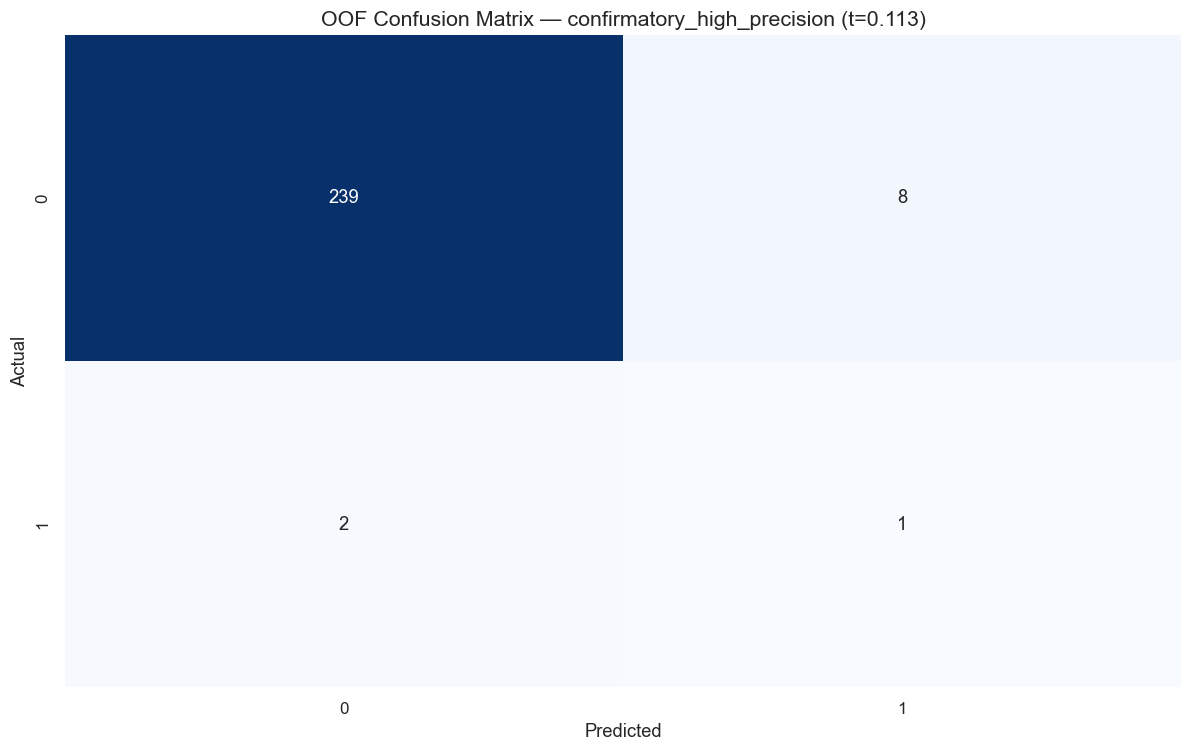

✓ Saved: results/plots/section4_cm_confirmatory_high_precision.png

✓ Saved: results/reports/section4_mode_reports.json


In [10]:
def plot_cm(cm, title, out_path):
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print("✓ Saved:", out_path)

mode_reports = {}

for mode, info in threshold_choices.items():
    t = float(info["threshold"])
    y_hat = (oof_proba >= t).astype(int)
    cm = confusion_matrix(y, y_hat)
    rep = classification_report(y, y_hat, digits=4, zero_division=0)

    print("\n" + "-"*100)
    print(mode, "threshold=", t)
    print("Confusion matrix:\n", cm)
    print("Report:\n", rep)

    out_path = f"results/plots/section4_cm_{mode}.png"
    plot_cm(cm, f"OOF Confusion Matrix — {mode} (t={t:.3f})", out_path)

    mode_reports[mode] = {
        "threshold": t,
        "confusion_matrix": cm.tolist(),
        "classification_report": rep
    }

with open("results/reports/section4_mode_reports.json", "w") as f:
    json.dump({
        "generated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "mode_reports": mode_reports
    }, f, indent=2)

print("\n✓ Saved: results/reports/section4_mode_reports.json")


---

## CELL 4.9: TRAIN FINAL MODEL ON FULL DATA + SAVE ARTIFACTS

We train a single final pipeline on **all data** (drop version) so you can deploy.


In [11]:
# scale_pos_weight on full dataset
neg_full = int((y == 0).sum())
pos_full = int((y == 1).sum())
spw_full = neg_full / max(pos_full, 1)

final_model = xgb.XGBClassifier(
    n_estimators=2500,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=2.0,
    min_child_weight=2,
    gamma=0,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=spw_full,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

final_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_drop),
    ("model", final_model)
])

final_pipeline.fit(X_drop, y)

joblib.dump(preprocess_drop, "models/section4_preprocess_drop.joblib")
joblib.dump(final_pipeline, "models/section4_xgb_drop_pipeline.joblib")

# Save raw XGBoost model too
final_pipeline.named_steps["model"].save_model("models/section4_xgb_drop_model.json")

# Save final summary
summary = {
    "generated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "data_path": DATA_PATH,
    "dropped_columns": DROP_COLS,
    "n_samples": int(len(y)),
    "n_pos": int(pos_full),
    "n_neg": int(neg_full),
    "scale_pos_weight_full": float(spw_full),
    "oof_pr_auc": float(oof_pr_auc),
    "oof_roc_auc": float(oof_roc_auc),
    "threshold_choices": threshold_choices
}

with open("results/reports/section4_final_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*100)
print("CELL 4.9 COMPLETE: FINAL MODEL SAVED")
print("="*100)
print("Saved:")
print("  models/section4_preprocess_drop.joblib")
print("  models/section4_xgb_drop_pipeline.joblib")
print("  models/section4_xgb_drop_model.json")
print("  results/reports/section4_final_summary.json")



CELL 4.9 COMPLETE: FINAL MODEL SAVED
Saved:
  models/section4_preprocess_drop.joblib
  models/section4_xgb_drop_pipeline.joblib
  models/section4_xgb_drop_model.json
  results/reports/section4_final_summary.json


---

## CELL 4.10: FINAL CHECKPOINT — VERIFY REQUIRED FILES EXIST

Ensures all reports, plots, and models were saved.


In [12]:
required_files = [
    "data/splits/section4_X_train.csv",
    "data/splits/section4_X_test.csv",
    "data/splits/section4_y_train.csv",
    "data/splits/section4_y_test.csv",
    "results/reports/section4_oof_3fold_folds.csv",
    "results/reports/section4_oof_3fold_predictions.csv",
    "results/reports/section4_threshold_sweep.csv",
    "results/reports/section4_threshold_choices.json",
    "results/reports/section4_mode_reports.json",
    "results/reports/section4_final_summary.json",
    "results/plots/section4_oof_pr_curve.png",
    "results/plots/section4_oof_roc_curve.png",
    "results/plots/section4_threshold_sweep.png",
    "models/section4_preprocess_drop.joblib",
    "models/section4_xgb_drop_pipeline.joblib",
    "models/section4_xgb_drop_model.json"
]

missing = [p for p in required_files if not os.path.exists(p)]

print("\n" + "="*100)
print("CELL 4.10: CHECKPOINT")
print("="*100)

if len(missing) == 0:
    print("✓✓✓ SECTION 4 COMPLETE — ALL ARTIFACTS SAVED ✓✓✓")
else:
    print("⚠ Missing files:")
    for p in missing:
        print("  -", p)

print("\nNext: SECTION 5 — Explainability (Feature Importance + SHAP) and Final Report")
print("="*100)



CELL 4.10: CHECKPOINT
✓✓✓ SECTION 4 COMPLETE — ALL ARTIFACTS SAVED ✓✓✓

Next: SECTION 5 — Explainability (Feature Importance + SHAP) and Final Report
